# 인물(Person) 탐지 모델 학습 — 최종 통합본

업로드해주신 6개 노트북(`training`, `complete`, `final`, `final_clean`, `final_fixed`, `finale`)을 전부 분석해서, **`final_clean`의 설정과 구조를 기준**으로 통합·수정한 최종 버전입니다.

## 발견한 문제 (기존 `final_clean`)

코드를 셀 단위로 뜯어본 결과, 실행 결과(34 epoch까지 진행되고 `NameError`로 멈춘 기록)까지 확인했습니다. 원인은 명확했습니다.

- **치명적 버그**: 학습 루프(`for epoch in range(...)`) 안에서 `train_one_epoch(...)`을 호출하는데, 정작 `train_one_epoch` 함수 정의 자체가 노트북에서 통째로 빠져 있었습니다. (`NameError: name 'train_one_epoch' is not defined`) → 다른 파일(`final`, `final_fixed`)에는 이 함수가 남아 있어서, 원래 어떤 형태였는지 복원해 다시 넣었습니다.
- **체크포인트 상태 오염**: 학습 재개(resume) 로직 뒤에, 디버깅용으로 보이는 셀들이 이어지면서 `best` 체크포인트를 모델에 다시 덮어씌우고 있었습니다. 그런데 `best_f1`/`early_stop_counter` 같은 변수는 여전히 `last` 체크포인트 기준이라, "epoch 번호"와 "실제 모델 가중치"가 서로 다른 시점을 가리키는 상태로 학습이 재개될 뻔했습니다. → 이번 버전에서는 이런 디버그성 셀들을 제거하고, resume 로직을 한 셀로 깔끔하게 정리했습니다.
- **정의만 되고 쓰이지 않은 설정값**: `GRAD_CLIP_NORM`이 config에는 있었지만 실제 학습 코드에는 적용되어 있지 않았습니다. → `train_one_epoch`에 실제로 적용했습니다.

## 이번 버전에서 추가/개선한 부분

1. **100 epoch 강제 실행**: `USE_EARLY_STOPPING = False` (기본값)로, 10 epoch 연속 개선이 없어도 멈추지 않고 100 epoch을 끝까지 진행합니다. 필요하면 언제든 다시 켤 수 있게 남겨뒀습니다.
2. **격자(Grid) 해상도를 16px → 8px로 세분화**: 학습 데이터 중 한 이미지에 사람이 15명 가까이, 아주 촘촘하게 붙어 있는 경우들이 보였습니다. 기존 15×20 격자(칸 하나가 16×16px)는 사람 두세 명이 한 칸에 겹쳐 들어가 버려서 구조적으로 놓칠 수밖에 없었습니다. 격자를 30×40(칸 하나 8×8px)으로 세분화하고, 그만큼 백본에 층을 하나 더 추가해 표현력도 보강했습니다. (자세한 설명은 모델 정의 셀 참고)
3. **Gradient Clipping 실제 적용, AMP(혼합정밀도) 최신 API로 통일**
4. **평가 지표에 Box IoU 추가**: 기존 Precision/Recall/F1은 "그 칸에 사람이 있는지 없는지"만 봅니다. 박스 위치가 실제로 얼마나 정확한지 보려고 IoU(겹침 비율)를 추가했습니다.
5. **NMS(Non-Max Suppression) 추가**: 이웃한 칸들이 같은 사람을 중복으로 잡아내는 것을 정리합니다.
6. **에폭마다 "왜 best로 저장됐는지" 명시적으로 출력** + **10 epoch마다 검증 이미지 예측 스냅샷을 파일로 저장**해서, 학습이 진행되며 실제로 무엇이 달라지는지 눈으로 볼 수 있게 했습니다.
7. **여러 컴퓨터에서 설정 바꿔가며 비교하기 쉽도록** `EXPERIMENT_NAME` 기준으로 결과 폴더를 분리하고, GPU/환경 정보도 자동 기록합니다. (맨 아래 "비교 실험 가이드" 참고)
8. 실험 삼아 바꿔볼 수 있는 값에는 전부 `🔧 [실험 가능]` 표시를 해뒀습니다.

## 사용 방법

셀을 위에서 아래로 순서대로 실행하면 됩니다. 대부분의 실험은 **"⚙️ 실험 설정" 셀 하나만 수정**하면 됩니다.

## 실행 전 준비 (Anaconda)

이 노트북은 패키지를 자동으로 설치하지 않습니다. (자동 설치 스크립트가 `pip`로 CPU 전용 PyTorch를 깔아버려서 오히려 GPU 설정을 망가뜨리는 경우가 있어서, 일부러 넣지 않았습니다.) 아래 명령을 **Anaconda Prompt**에서 먼저 실행해 가상환경을 준비하세요.

```bash
conda create -n deeplearning python=3.11 -y
conda activate deeplearning

python -m pip install --upgrade pip setuptools wheel
conda install -y -c conda-forge pillow tqdm matplotlib pandas numpy ipykernel
conda install -y -c conda-forge albumentations

# GPU(CUDA) 버전 PyTorch - 본인 CUDA 버전에 맞게 설치
# 예: CUDA 12.1
conda install -y -c pytorch -c nvidia pytorch torchvision torchaudio pytorch-cuda=12.1

# 설치 확인
python -c "import torch; print(torch.__version__, torch.cuda.is_available())"
```

`torch.cuda.is_available()`이 `True`로 나와야 GPU로 학습됩니다. `False`가 나오면 NVIDIA 드라이버 버전과 `pytorch-cuda=` 버전이 맞는지 확인하세요.

설치 후 Jupyter에서 이 `deeplearning` 커널을 선택하고, 커널을 완전히 재시작한 뒤 아래 셀부터 순서대로 실행하세요.

같은 컴퓨터에서 이미 `final_clean.ipynb`을 34 epoch까지 돌려본 적이 있다면(로그가 있다면), 환경은 이미 준비되어 있는 것이니 이 셀은 건너뛰어도 됩니다.

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================
import os
import sys
import json
import time
import random
import platform

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import albumentations as A

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tqdm.auto import tqdm

# ------------------------------------------------------------
# matplotlib 한글 폰트 설정
#
# matplotlib 기본 폰트(DejaVu Sans)는 한글을 지원하지 않아서, 그대로
# 두면 그래프/이미지에 들어가는 한글이 네모(□)로 깨져 보입니다.
# Windows에 기본 내장된 '맑은 고딕(Malgun Gothic)'을 우선 사용하고,
# 없으면(Mac/Linux) NanumGothic 등을 시도한 뒤, 그래도 없으면 그냥
# 기본 폰트로 넘어갑니다(이 경우 그래프의 한글 글자만 깨지고, 학습 자체에는
# 영향이 없습니다).
# ------------------------------------------------------------
import matplotlib.font_manager as fm

_installed_fonts = {f.name for f in fm.fontManager.ttflist}
for _font_name in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]:
    if _font_name in _installed_fonts:
        plt.rcParams["font.family"] = _font_name
        break
plt.rcParams["axes.unicode_minus"] = False  # 한글 폰트 사용 시 마이너스(-) 기호 깨짐 방지

print("=" * 70)
print("실행 환경 정보")
print("=" * 70)
print("Python 실행 경로 :", sys.executable)
print("Python 버전      :", platform.python_version())
print("OS               :", platform.platform())
print("PyTorch 버전     :", torch.__version__)
print("CUDA 사용 가능   :", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 Device      :", device)

env_info = {
    "python_version": platform.python_version(),
    "os": platform.platform(),
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "device": str(device),
}

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = gpu_props.total_memory / (1024 ** 3)

    print("GPU 이름         :", gpu_name)
    print(f"GPU VRAM         : {gpu_vram_gb:.2f} GB")
    print("CUDA Capability  :", f"{gpu_props.major}.{gpu_props.minor}")
    print("cuDNN 버전       :", torch.backends.cudnn.version())

    env_info.update({
        "gpu_name": gpu_name,
        "gpu_vram_gb": round(gpu_vram_gb, 2),
        "cuda_capability": f"{gpu_props.major}.{gpu_props.minor}",
        "cudnn_version": torch.backends.cudnn.version(),
    })

    # VRAM이 작은 GPU(예: 2~4GB급 노트북 GPU)라면 BATCH_SIZE나 IMAGE 크기를
    # 키울 때 CUDA out of memory가 날 수 있습니다. 아래 "⚙️ 실험 설정" 셀에서
    # BATCH_SIZE를 줄여보세요.
    if gpu_vram_gb < 6:
        print(f"⚠️ VRAM이 {gpu_vram_gb:.1f}GB로 넉넉하지 않습니다. 만약 학습 중")
        print("   'CUDA out of memory' 오류가 발생하면 BATCH_SIZE를 32 → 16 → 8 순으로")
        print("   줄여보세요. (뒤에서 여러 대의 컴퓨터를 비교할 때도 참고하세요)")
else:
    print("⚠️ GPU(CUDA)를 찾지 못했습니다. NVIDIA GPU로 학습하려면:")
    print("   1) NVIDIA 드라이버가 설치되어 있는지 확인")
    print("   2) 위 설치 안내의 'pytorch-cuda=' 버전이 내 드라이버와 맞는지 확인")
    print("   CPU로도 실행은 되지만, 이 데이터셋 기준 100 epoch은 매우 오래 걸립니다.")

print("=" * 70)


# ------------------------------------------------------------
# 난수 시드 고정
#
# 같은 코드를 여러 번 돌려도 최대한 같은 결과가 나오게 고정합니다.
# (데이터 섞기 순서, 가중치 초기값, augmentation 랜덤성 등)
#
# 🔧 [실험 가능] 다른 컴퓨터에서 SEED만 다르게 주고 나머지 설정을 동일하게
#    돌려보면, "순수하게 운(랜덤성)만으로 결과가 얼마나 달라지는지"를
#    직접 확인할 수 있습니다. 이건 딥러닝을 공부할 때 꼭 한 번 해볼 만한
#    실험입니다 — 같은 코드인데 F1이 흔들린다면, 그 흔들림의 폭이 바로
#    "이 실험 세팅의 잡음 수준"입니다.
# ------------------------------------------------------------
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # cudnn.deterministic=True: 속도는 조금 손해보지만 재현성을 높입니다.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

실행 환경 정보
Python 실행 경로 : C:\Users\USER\anaconda3\python.exe
Python 버전      : 3.13.9
OS               : Windows-11-10.0.26200-SP0
PyTorch 버전     : 2.13.0+cpu
CUDA 사용 가능   : False
사용 Device      : cpu
⚠️ GPU(CUDA)를 찾지 못했습니다. NVIDIA GPU로 학습하려면:
   1) NVIDIA 드라이버가 설치되어 있는지 확인
   2) 위 설치 안내의 'pytorch-cuda=' 버전이 내 드라이버와 맞는지 확인
   CPU로도 실행은 되지만, 이 데이터셋 기준 100 epoch은 매우 오래 걸립니다.


In [2]:
# ============================================================
# ⚙️ 실험 설정 (Config)
#
# 여러 컴퓨터에서 조건을 바꿔가며 비교 실험을 할 계획이라면,
# 대부분 이 셀 하나만 고치면 됩니다. 🔧 표시가 있는 값들이
# "바꿔서 실험해볼 만한" 값입니다. 표시가 없는 값들은 데이터셋
# 구조나 모델 구조와 맞물려 있어서, 바꾸려면 다른 셀도 같이
# 고쳐야 할 수 있습니다 (해당 위치에 설명해두었습니다).
# ============================================================

# ------------------------------------------------------------
# 실험 이름
#
# 🔧 [실험 가능] 컴퓨터/조건마다 다른 이름을 주세요. (예: "baseline",
#    "lr_1e-4", "no_aug", "batch32" 등) 이 이름 아래로 체크포인트・로그・
#    결과가 전부 따로 저장되므로, 나중에 여러 컴퓨터의 logs 폴더를
#    한 곳에 모아놓고 training_log.csv끼리 바로 비교할 수 있습니다.
#    같은 이름을 계속 쓰면 그 실험을 이어서 학습(resume)하게 됩니다.
# ------------------------------------------------------------
EXPERIMENT_NAME = "best_setting_03"

# ------------------------------------------------------------
# 데이터셋 경로
#
# 현재 예상하는 폴더 구조 (Roboflow류 export 구조와 동일):
#   archive/
#     train/train/_annotations.csv, *.jpg ...
#     valid/valid/_annotations.csv, *.jpg ...
#     test/test/_annotations.csv,  *.jpg ...
#   annotations.csv 컬럼: filename, width, height, class, xmin, ymin, xmax, ymax
#
# 다른 데이터셋을 쓰려면 이 부분과, 바로 아래 PersonDataset 클래스의
# "class" 필터링 부분을 같이 확인하세요.
# ------------------------------------------------------------
ROOT = "./archive"

# ------------------------------------------------------------
# 이미지 크기
#
# 320x240: 속도와 정확도의 균형이 맞는 기본값입니다.
#
# 🔧 [실험 가능] 416x416, 512x384 처럼 키우면:
#      정확도 ↑ (작은 사람도 더 잘 보임) / GPU 메모리 사용량 ↑ / 학습 시간 ↑
#    VRAM이 작은 GPU(4GB 미만)에서 이미지 크기를 키운다면 BATCH_SIZE를
#    같이 줄여야 'CUDA out of memory'를 피할 수 있습니다.
# ------------------------------------------------------------
IMAGE_WIDTH = 320
IMAGE_HEIGHT = 240

# ------------------------------------------------------------
# 격자(Grid) 다운샘플 비율 — ⚠️ 실험용 값 아님, 모델 구조와 반드시 같이 바꿔야 함
#
# 이 모델은 이미지를 (GRID_H x GRID_W) 격자로 나눠서, 격자 한 칸마다
# "사람이 있는지 + 박스 위치"를 예측하는 방식(YOLO v1과 비슷한 방식)입니다.
# DOWNSAMPLE=8은 "모델을 통과하면 가로/세로가 1/8로 줄어든다"는 뜻이고,
# 이는 아래쪽 Backbone 클래스의 MaxPool 개수(3번)로 결정됩니다.
#
# 원래 final_clean 버전은 DOWNSAMPLE=16(격자 15x20, 칸 하나 16x16px)이었는데,
# 실제 데이터를 보니 한 이미지에 사람이 10명 이상 아주 가깝게 붙어있는
# 경우가 많아서(예: 중심점 간 거리가 12px 정도) 16px 격자 한 칸에 사람이
# 여러 명 겹쳐 들어가 구조적으로 놓치는 문제가 있었습니다. 그래서 이번
# 버전은 DOWNSAMPLE=8(격자 30x40, 칸 하나 8x8px)로 세분화했습니다.
#
# 이 값을 바꾸고 싶다면, 아래 "모델 정의" 셀의 Backbone 클래스에서
# MaxPool2d 개수를 함께 바꿔야 합니다 (MaxPool 1번당 다운샘플 2배).
# ------------------------------------------------------------
DOWNSAMPLE = 8
GRID_W = IMAGE_WIDTH // DOWNSAMPLE    # 320 // 8 = 40
GRID_H = IMAGE_HEIGHT // DOWNSAMPLE   # 240 // 8 = 30

# ------------------------------------------------------------
# 학습 하이퍼파라미터
# ------------------------------------------------------------

# 🔧 [실험 가능] 한 번에 몇 장씩 묶어서 학습할지. 크면 학습이 (보통) 더
#    안정적이고 빠르지만 GPU 메모리를 더 씁니다. VRAM이 작다면 32/16으로.
BATCH_SIZE = 8

# 요청하신 대로 100 epoch을 "무조건" 끝까지 돕니다.
# (아래 USE_EARLY_STOPPING=False가 이 요청을 실제로 보장하는 값입니다)
#
# 🔧 [실험 가능] 시간이 부족해서 짧게 테스트만 해보고 싶다면 5~10으로
#    낮춰서 파이프라인이 잘 도는지 먼저 확인해보는 것도 좋습니다.
NUM_EPOCHS = 100

# 🔧 [실험 가능] 학습률. 너무 크면 loss가 튀거나 발산하고, 너무 작으면
#    학습이 느립니다. 이 모델/데이터 기준 1e-3이 기본값으로 무난합니다.
#    한 자리 낮춘 1e-4, 높인 3e-3 등을 다른 컴퓨터에서 비교해보세요.
LEARNING_RATE = 5e-4

# 🔧 [실험 가능] L2 정규화 강도. 과적합(train은 좋아지는데 valid는 안 좋아짐)이
#    보이면 조금 올려보세요 (예: 1e-4).
WEIGHT_DECAY = 1e-4

# 🔧 [실험 가능] Loss 안에서 "박스 위치 정확도"에 얼마나 가중치를 둘지.
#    올리면 위치는 더 정확해지려 하지만 객체 유무 판별(정확도) 학습에는
#    상대적으로 덜 집중하게 됩니다.
BOX_LOSS_WEIGHT = 5.0

# 🔧 [실험 가능] 학습 중 Precision/Recall/F1을 계산할 때 "이 확률 이상이면
#    사람이 있다고 본다"는 기준. 학습 자체나 best 모델 선정에는 쓰이지만,
#    학습이 끝나면 검증셋에서 이 값과 무관하게 최적 threshold를 다시
#    탐색합니다 (뒤쪽 "Best 모델 로드 + threshold 탐색" 셀 참고).
CONF_THRESHOLD = 0.25

# 🔧 [실험 가능] NMS(중복 박스 제거)에서 "이 정도 겹치면 같은 사람으로 본다"는
#    기준. 낮추면 중복 제거를 더 공격적으로 합니다.
NMS_IOU_THRESHOLD = 0.45

# ------------------------------------------------------------
# Early Stopping
#
# 기존 final_clean은 PATIENCE(10) epoch 동안 F1이 개선되지 않으면
# 자동으로 학습을 멈췄습니다. 요청하신 대로, 이번 기본값은 "100 epoch을
# 무조건 끝까지 진행"하도록 USE_EARLY_STOPPING=False로 꺼져 있습니다.
# best 모델 저장 자체는 USE_EARLY_STOPPING 값과 무관하게 계속 동작합니다
# (즉, F1이 중간에 나빠져도 100 epoch을 다 돌고, 그 중 가장 좋았던
# epoch의 가중치가 best로 남습니다).
#
# 🔧 [실험 가능] 다른 컴퓨터에서 "Early Stopping을 쓰면 실제로 몇 epoch
#    만에 멈추는지, 100 epoch을 다 돈 것과 최종 성능 차이가 얼마나 나는지"
#    비교해보는 것도 좋은 실험입니다. True로 바꾸면 PATIENCE가 적용됩니다.
# ------------------------------------------------------------
USE_EARLY_STOPPING = True
PATIENCE = 15

# 🔧 [실험 가능] ReduceLROnPlateau 스케줄러 설정. F1이 SCHEDULER_PATIENCE
#    epoch 동안 개선되지 않으면 학습률을 SCHEDULER_FACTOR배로 줄입니다.
SCHEDULER_PATIENCE = 5
SCHEDULER_FACTOR = 0.5

# 🔧 [실험 가능] Gradient Clipping 강도. loss가 갑자기 튀는(gradient explosion)
#    현상을 막아줍니다. final_clean에는 값만 정의되어 있고 실제로는
#    적용되어 있지 않던 부분이라, 이번 버전에서 실제로 적용했습니다.
GRAD_CLIP_NORM = 5.0

# 🔧 [실험 가능] 혼합정밀도(Mixed Precision, FP16) 학습 사용 여부.
#    NVIDIA GPU에서는 켜두면 메모리를 덜 쓰고 보통 더 빠릅니다.
#    CPU에서는 이 값과 무관하게 항상 꺼진 것처럼 동작합니다(자동 처리).
#    다른 컴퓨터에서 True/False 켜고 꺼서 "속도"와 "최종 성능"을
#    비교해보면 AMP의 효과를 직접 체감할 수 있습니다.
USE_AMP = True

# 🔧 [실험 가능] DataLoader가 데이터를 몇 개의 별도 프로세스로 미리
#    읽어올지. 0이면 메인 프로세스에서 순차적으로 읽습니다(Windows에서
#    가장 안전). Linux/Mac이거나 Windows에서 문제가 없다면 2~4로 올리면
#    데이터 로딩이 더 빨라질 수 있습니다.
NUM_WORKERS = 0

# 마지막(last) 체크포인트가 있으면 이어서 학습할지 여부.
# 컴퓨터가 도중에 꺼지거나 Jupyter 커널이 죽어도, RESUME=True면
# 처음부터 다시 돌리지 않고 이어서 진행할 수 있습니다.
RESUME = True

# 🔧 [실험 가능] 난수 시드 (위 "seed_everything" 설명 참고)
SEED = 42

# 🔧 [실험 가능] 몇 epoch마다 검증 이미지 예측 스냅샷을 파일로 저장할지.
#    학습 중간 결과를 눈으로 확인하고 싶으면 낮추고(예: 5), 학습 속도가
#    더 중요하면 높이세요(예: 20).
SNAPSHOT_EVERY = 20


# 지금까지 설정한 값들을 한 번에 확인
print("=" * 70)
print("실험 설정 (Config)")
print("=" * 70)
print(f"실험 이름         : {EXPERIMENT_NAME}")
print(f"이미지 크기       : {IMAGE_WIDTH} x {IMAGE_HEIGHT}")
print(f"격자 크기         : {GRID_W} x {GRID_H}  (다운샘플 {DOWNSAMPLE}배)")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Epoch             : {NUM_EPOCHS}")
print(f"Learning Rate     : {LEARNING_RATE}")
print(f"Weight Decay      : {WEIGHT_DECAY}")
print(f"Box Loss Weight   : {BOX_LOSS_WEIGHT}")
print(f"Grad Clip Norm    : {GRAD_CLIP_NORM}")
print(f"Mixed Precision   : {USE_AMP}")
print(f"Early Stopping    : {USE_EARLY_STOPPING} (Patience={PATIENCE})")
print(f"Resume            : {RESUME}")
print(f"Seed              : {SEED}")
print("=" * 70)

# 시드는 데이터셋/모델을 만들기 "전에" 고정해야 의미가 있으므로 여기서 바로 실행합니다.
seed_everything(SEED)
print(f"Random Seed 고정 완료: {SEED}")

실험 설정 (Config)
실험 이름         : best_setting_03
이미지 크기       : 320 x 240
격자 크기         : 40 x 30  (다운샘플 8배)
Batch Size        : 8
Epoch             : 100
Learning Rate     : 0.0005
Weight Decay      : 0.0001
Box Loss Weight   : 5.0
Grad Clip Norm    : 5.0
Mixed Precision   : True
Early Stopping    : True (Patience=15)
Resume            : True
Seed              : 42
Random Seed 고정 완료: 42


In [3]:
# ============================================================
# 경로 설정 + 결과 폴더 생성
#
# EXPERIMENT_NAME별로 폴더가 나뉘기 때문에, 다른 컴퓨터/다른 설정으로
# 여러 번 실험해도 결과가 서로 덮어써지지 않습니다.
#
#   checkpoints/<실험이름>/person_detector_best.pth   ← 가장 성능 좋은 모델
#   checkpoints/<실험이름>/person_detector_last.pth   ← 가장 최근 epoch (재시작용)
#   logs/<실험이름>/training_log.csv                  ← epoch별 기록 (표/그래프용)
#   logs/<실험이름>/config.json                       ← 이번 실험에 쓴 설정값
#   logs/<실험이름>/env_info.json                     ← 이 실험을 돌린 컴퓨터 환경
#   logs/<실험이름>/threshold_sweep.csv                ← threshold 탐색 결과
#   results/<실험이름>/predictions/epoch_XXX.png       ← 학습 중 예측 스냅샷
#   results/<실험이름>/person_detector_script.pt        ← 배포용 TorchScript
# ============================================================

TRAIN_DIR = os.path.join(ROOT, "train", "train")
VALID_DIR = os.path.join(ROOT, "valid", "valid")
TEST_DIR = os.path.join(ROOT, "test", "test")

TRAIN_CSV = os.path.join(TRAIN_DIR, "_annotations.csv")
VALID_CSV = os.path.join(VALID_DIR, "_annotations.csv")
TEST_CSV = os.path.join(TEST_DIR, "_annotations.csv")

CHECKPOINT_DIR = os.path.join("checkpoints", EXPERIMENT_NAME)
LOG_DIR = os.path.join("logs", EXPERIMENT_NAME)
RESULT_DIR = os.path.join("results", EXPERIMENT_NAME)
PREDICT_DIR = os.path.join(RESULT_DIR, "predictions")

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "person_detector_best.pth")
LAST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "person_detector_last.pth")
LOG_CSV_PATH = os.path.join(LOG_DIR, "training_log.csv")
CONFIG_PATH = os.path.join(LOG_DIR, "config.json")
ENV_INFO_PATH = os.path.join(LOG_DIR, "env_info.json")
THRESHOLD_CSV_PATH = os.path.join(LOG_DIR, "threshold_sweep.csv")
SCRIPT_PATH = os.path.join(RESULT_DIR, "person_detector_script.pt")

for d in [CHECKPOINT_DIR, LOG_DIR, RESULT_DIR, PREDICT_DIR]:
    os.makedirs(d, exist_ok=True)

print("데이터 경로 확인")
print(" TRAIN_CSV:", TRAIN_CSV, "->", os.path.exists(TRAIN_CSV))
print(" VALID_CSV:", VALID_CSV, "->", os.path.exists(VALID_CSV))
print(" TEST_CSV :", TEST_CSV, "->", os.path.exists(TEST_CSV))

assert os.path.exists(TRAIN_CSV), f"TRAIN_CSV가 없습니다: {TRAIN_CSV} (ROOT 경로를 확인하세요)"
assert os.path.exists(VALID_CSV), f"VALID_CSV가 없습니다: {VALID_CSV}"
assert os.path.exists(TEST_CSV), f"TEST_CSV가 없습니다: {TEST_CSV}"

config = {
    "experiment_name": EXPERIMENT_NAME,
    "root": ROOT,
    "image_width": IMAGE_WIDTH,
    "image_height": IMAGE_HEIGHT,
    "downsample": DOWNSAMPLE,
    "grid_w": GRID_W,
    "grid_h": GRID_H,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "box_loss_weight": BOX_LOSS_WEIGHT,
    "conf_threshold": CONF_THRESHOLD,
    "nms_iou_threshold": NMS_IOU_THRESHOLD,
    "use_early_stopping": USE_EARLY_STOPPING,
    "patience": PATIENCE,
    "scheduler_patience": SCHEDULER_PATIENCE,
    "scheduler_factor": SCHEDULER_FACTOR,
    "grad_clip_norm": GRAD_CLIP_NORM,
    "use_amp": USE_AMP,
    "num_workers": NUM_WORKERS,
    "resume": RESUME,
    "seed": SEED,
    "snapshot_every": SNAPSHOT_EVERY,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

with open(ENV_INFO_PATH, "w", encoding="utf-8") as f:
    json.dump(env_info, f, ensure_ascii=False, indent=2)

print(f"\nConfig 저장 완료   : {CONFIG_PATH}")
print(f"환경 정보 저장 완료: {ENV_INFO_PATH}")

데이터 경로 확인
 TRAIN_CSV: ./archive\train\train\_annotations.csv -> True
 VALID_CSV: ./archive\valid\valid\_annotations.csv -> True
 TEST_CSV : ./archive\test\test\_annotations.csv -> True

Config 저장 완료   : logs\best_setting_03\config.json
환경 정보 저장 완료: logs\best_setting_03\env_info.json


In [4]:
# ============================================================
# 데이터 증강 (Data Augmentation)
#
# 같은 사진을 매 epoch마다 살짝씩 다르게 보여줘서, 모델이 특정 각도・
# 밝기・위치에만 익숙해지는 것(과적합)을 막습니다. 학습(train)에만
# 적용하고, valid/test에는 적용하지 않습니다(공정한 평가를 위해).
#
#   - HorizontalFlip     : 50% 확률로 좌우 반전
#   - RandomBrightnessContrast : 50% 확률로 밝기/대비를 랜덤하게 조절
#   - Affine              : 50% 확률로 살짝 확대/축소(90~110%), 이동(±5%),
#                            회전(±5도) — 너무 크게 돌리면 사람 형태가
#                            부자연스러워지므로 값을 작게 유지했습니다.
#
# bbox_params: augmentation으로 이미지가 변형될 때 박스 좌표도 같이
# 맞춰서 변형해줍니다. min_visibility=0.2는 "변형 후 박스 면적이
# 원래의 20% 미만으로 잘려나가면 그 박스는 버린다"는 뜻입니다
# (거의 안 보이는 사람까지 정답으로 우기지 않기 위함).
#
# 🔧 [실험 가능] 아래는 추가로 시도해볼 만한 augmentation입니다
#    (성능이 항상 좋아지는 건 아니니, 비교 실험으로 확인해보세요):
#      A.RandomShadow(p=0.2)      : 그림자 효과
#      A.GaussianBlur(p=0.1)      : 살짝 흐릿하게 (저화질 CCTV 대비)
#      A.HueSaturationValue(p=0.3): 색감 변화
#    p 값이나 Affine의 rotate/scale 범위를 조절하는 것만으로도
#    결과가 꽤 달라질 수 있습니다.
# ============================================================
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.Affine(
            scale=(0.9, 1.1),
            translate_percent=0.05,
            rotate=(-5, 5),
            p=0.5,
        ),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",       # [xmin, ymin, xmax, ymax] 픽셀 좌표
        label_fields=["labels"],
        min_visibility=0.2,
    ),
)

print("train_transform 정의 완료:")
print(train_transform)

train_transform 정의 완료:
Compose([
  HorizontalFlip(p=0.5),
  RandomBrightnessContrast(p=0.5, brightness_by_max=True, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), ensure_safe_range=False),
  Affine(p=0.5, balanced_scale=False, border_mode=0, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(-5.0, 5.0), rotate_method='largest_box', scale={'x': (0.9, 1.1), 'y': (0.9, 1.1)}, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, translate_percent={'x': (0.05, 0.05), 'y': (0.05, 0.05)}, translate_px=None),
], p=1.0, bbox_params={'format': 'pascal_voc', 'label_fields': ['labels'], 'min_area': 0.0, 'min_visibility': 0.2, 'min_width': 0.0, 'min_height': 0.0, 'check_each_transform': True, 'clip': False, 'max_accept_ratio': None}, keypoint_params=None, additional_targets={}, is_check_shapes=True)


In [5]:
# ============================================================
# Dataset 클래스
#
# PyTorch가 학습 중에 "이미지 한 장 + 그 안의 사람 박스들"을
# 하나씩 꺼내갈 수 있게 해주는 클래스입니다. 역할을 순서대로 보면:
#
#   1. __init__   : csv를 읽고, class가 "person"인 행만 남긴 뒤,
#                   이미지 파일 이름 목록을 만든다.
#   2. __len__    : 전체 이미지 장수를 알려준다.
#   3. __getitem__: index 하나를 받아서
#                     (a) 이미지를 열고 RGB로 변환
#                     (b) 그 이미지에 속한 모든 사람 박스를 모은다
#                     (c) (학습용이면) augmentation 적용
#                     (d) 모델 입력 크기(IMAGE_WIDTH x IMAGE_HEIGHT)로
#                         리사이즈하고, 박스 좌표도 같은 비율로 조정
#                     (e) 0~1 사이 값으로 정규화하고 Tensor로 변환
#                   해서 돌려준다.
#
# 주의: 이미지마다 사람 수가 다르기 때문에(0명~15명 이상), boxes의
# shape이 이미지마다 다릅니다. 그래서 DataLoader의 기본 방식으로는
# 여러 장을 하나의 배치로 묶을 수 없고, 바로 아래에서 정의하는
# collate_fn이 필요합니다.
# ============================================================
class PersonDataset(Dataset):
    def __init__(self, image_dir, csv_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        self.df = pd.read_csv(csv_file)
        # 이 프로젝트는 "사람(person)"만 탐지하는 것이 목표이므로,
        # 다른 클래스(예: car, dog 등)가 섞여 있는 csv라도 person 행만 사용합니다.
        self.df = self.df[self.df["class"] == "person"].copy()
        self.image_list = sorted(self.df["filename"].unique())

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        filename = self.image_list[idx]
        rows = self.df[self.df["filename"] == filename]

        image_path = os.path.join(self.image_dir, filename)
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {image_path}")

        image = Image.open(image_path).convert("RGB")
        image = np.array(image)

        # 이 이미지에 속한 모든 사람 박스를 모읍니다.
        boxes = []
        for _, row in rows.iterrows():
            xmin = float(row["xmin"])
            ymin = float(row["ymin"])
            xmax = float(row["xmax"])
            ymax = float(row["ymax"])

            # 폭/높이가 1px 이하인 잘못된 박스(라벨링 오류 등)는 제외
            if xmax - xmin > 1 and ymax - ymin > 1:
                boxes.append([xmin, ymin, xmax, ymax])

        boxes = np.array(boxes, dtype=np.float32)

        # 학습용 데이터라면 augmentation 적용 (박스가 하나도 없으면 생략)
        if self.transform is not None and len(boxes) > 0:
            transformed = self.transform(
                image=image,
                bboxes=boxes.tolist(),
                labels=[1] * len(boxes),
            )
            image = transformed["image"]
            boxes = np.array(transformed["bboxes"], dtype=np.float32)

        # 원본 이미지 크기 → 모델 입력 크기로 리사이즈
        h, w = image.shape[:2]
        sx = IMAGE_WIDTH / w
        sy = IMAGE_HEIGHT / h

        resample = getattr(Image, "Resampling", Image).BILINEAR
        image = Image.fromarray(image.astype(np.uint8)).resize(
            (IMAGE_WIDTH, IMAGE_HEIGHT), resample=resample
        )
        image = np.array(image)
        image = image.astype(np.float32) / 255.0     # 0~255 -> 0~1
        image = np.transpose(image, (2, 0, 1))         # HWC -> CHW (PyTorch 표준)

        # 이미지가 리사이즈된 비율만큼 박스 좌표도 같이 조정
        if len(boxes) > 0:
            boxes[:, [0, 2]] *= sx
            boxes[:, [1, 3]] *= sy
            boxes[:, [0, 2]] = np.clip(boxes[:, [0, 2]], 0, IMAGE_WIDTH)
            boxes[:, [1, 3]] = np.clip(boxes[:, [1, 3]], 0, IMAGE_HEIGHT)
        else:
            boxes = np.zeros((0, 4), dtype=np.float32)

        image = torch.tensor(image, dtype=torch.float32)
        boxes = torch.tensor(boxes, dtype=torch.float32)

        return image, boxes


def collate_fn(batch):
    """
    DataLoader가 여러 __getitem__ 결과를 하나의 배치로 묶을 때 쓰는 함수.
    이미지는 크기가 전부 같아서(IMAGE_WIDTH x IMAGE_HEIGHT) torch.stack으로
    바로 묶이지만, boxes는 이미지마다 개수가 달라서 하나의 Tensor로 합칠 수
    없기 때문에 리스트 형태로만 묶어서 반환합니다.
    """
    images = []
    boxes_list = []
    for img, boxes in batch:
        images.append(img)
        boxes_list.append(boxes)
    images = torch.stack(images, dim=0)
    return images, boxes_list


print("PersonDataset, collate_fn 정의 완료")

PersonDataset, collate_fn 정의 완료


In [6]:
# ============================================================
# Dataset / DataLoader 생성
#
# train_dataset : augmentation 적용 O
# val_dataset, test_dataset : augmentation 적용 X (있는 그대로 평가해야 공정함)
# ============================================================
train_dataset = PersonDataset(TRAIN_DIR, TRAIN_CSV, transform=train_transform)
val_dataset = PersonDataset(VALID_DIR, VALID_CSV, transform=None)
test_dataset = PersonDataset(TEST_DIR, TEST_CSV, transform=None)

print("이미지 장수")
print(f"  Train : {len(train_dataset)}")
print(f"  Valid : {len(val_dataset)}")
print(f"  Test  : {len(test_dataset)}")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=True,   # 마지막에 배치 크기보다 적게 남는 부분은 버려서 BatchNorm이 불안정해지는 것을 방지
)

valid_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(NUM_WORKERS > 0),
)

print("\n배치(batch) 개수")
print(f"  Train : {len(train_loader)} batches")
print(f"  Valid : {len(valid_loader)} batches")
print(f"  Test  : {len(test_loader)} batches")

이미지 장수
  Train : 13278
  Valid : 1370
  Test  : 738

배치(batch) 개수
  Train : 1659 batches
  Valid : 172 batches
  Test  : 93 batches


이미지 Tensor shape: torch.Size([3, 240, 320])
박스 개수          : 15
박스 좌표(xmin, ymin, xmax, ymax):
tensor([[ 72.2944,  65.8990, 117.2962, 121.1813],
        [121.7691,  71.6292, 142.9247, 120.3672],
        [148.4057,  63.5933, 182.4981, 119.9259],
        [235.2561,  49.7526, 249.7890,  62.7046],
        [248.0091,  45.4954, 284.1813,  68.2360],
        [185.7104, 199.1236, 199.3146, 240.0000],
        [198.5247, 198.9558, 209.5110, 240.0000],
        [212.8737, 200.2921, 227.8016, 237.0351],
        [265.2137, 196.6688, 273.3916, 235.3509],
        [273.4713, 194.4066, 286.2195, 236.0346],
        [286.2991, 195.0654, 295.7939, 222.2870],
        [247.5203, 198.1728, 256.5838, 222.1068],
        [233.9659, 199.2231, 242.6388, 222.3305],
        [226.0649, 200.1678, 235.1147, 223.2814],
        [311.9276, 194.6490, 320.0000, 218.5829]])


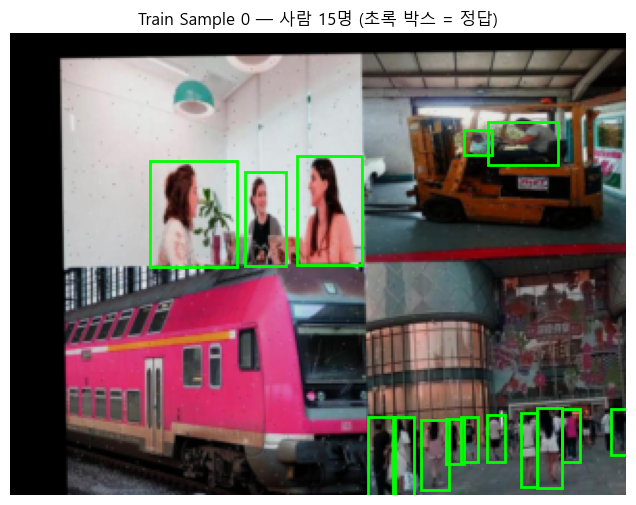

In [7]:
# ============================================================
# 샘플 시각화
#
# 학습을 시작하기 전에, 데이터가 제대로 로드되고 박스 좌표가
# 이미지 위에 올바르게 그려지는지 눈으로 확인하는 단계입니다.
# 여기서 박스 위치가 이상하게 보인다면(사람이 없는 곳에 박스가 있다거나),
# csv 좌표 형식이나 리사이즈 로직에 문제가 있다는 신호이니
# 학습을 시작하기 전에 반드시 확인하세요.
# ============================================================
sample_image, sample_boxes = train_dataset[0]

print("이미지 Tensor shape:", sample_image.shape)   # [3, H, W]
print("박스 개수          :", len(sample_boxes))
print("박스 좌표(xmin, ymin, xmax, ymax):")
print(sample_boxes)

image_vis = sample_image.permute(1, 2, 0).numpy()  # CHW -> HWC (matplotlib용)

plt.figure(figsize=(8, 6))
plt.imshow(image_vis)
ax = plt.gca()
for box in sample_boxes.numpy():
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle(
        (xmin, ymin), xmax - xmin, ymax - ymin,
        linewidth=2, edgecolor="lime", facecolor="none",
    )
    ax.add_patch(rect)
plt.title(f"Train Sample 0 — 사람 {len(sample_boxes)}명 (초록 박스 = 정답)")
plt.axis("off")
plt.show()

## 모델 구조

이 모델은 이미지 전체를 한 번에 보고, 이미지를 **격자(grid)**로 나눈 뒤 각 칸마다 "여기에 사람이 있는가?"와 "있다면 박스는 어디인가?"를 동시에 예측하는 방식입니다. (YOLO v1과 같은 계열의 아이디어를 최소한의 구성으로 직접 구현한 버전입니다.)

```
입력 이미지 (3, 240, 320)
        │
        ▼
   Backbone (합성곱 층들 — 이미지에서 특징을 뽑아내는 부분)
        │   240x320 → 120x160 → 60x80 → 30x40 (여기서부터는 해상도 유지, 층만 추가)
        ▼
   특징 맵 (256, 30, 40)
        │
        ▼
   Head (1x1 합성곱 — 칸마다 5개 숫자로 압축)
        │
        ▼
   출력 (5, 30, 40)
        채널 0   : 이 칸에 사람이 있을 확률 (objectness)
        채널 1~4 : 박스 위치 (중심 x, 중심 y, 너비, 높이) — 이미지 크기 대비 0~1 비율
```

30×40 = 1,200개의 칸 각각이 "나는 사람을 담당한다 / 아니다"를 판단하고, 담당한다면 박스 위치까지 같이 내놓는 구조입니다. 칸 하나의 실제 크기는 8×8px(=240/30, 320/40)입니다.

**왜 격자 한 칸이 8px인가?** 이 데이터셋에는 사람이 아주 촘촘하게 모여 있는 사진들이 있어서, 칸이 너무 크면(원래 설정이던 16px) 두 사람이 같은 칸에 들어가 버려 한 명을 놓치게 됩니다. 칸을 작게 쪼갤수록 이 충돌이 줄어들지만, 대신 계산량은 늘어납니다.

In [8]:
# ============================================================
# 모델 정의
# ============================================================
class ConvBlock(nn.Module):
    """Conv2d -> BatchNorm -> ReLU 를 한 세트로 묶은 기본 블록.
    BatchNorm은 학습을 안정적으로/빠르게 만들어주고, ReLU는 비선형성을 더해
    모델이 단순한 직선 관계보다 복잡한 패턴을 학습할 수 있게 해줍니다."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Backbone(nn.Module):
    """
    이미지에서 특징을 뽑아내는 부분. MaxPool2d를 지날 때마다 가로/세로가
    절반으로 줄어듭니다(=해상도를 낮추는 대신, 채널 수를 늘려 더 추상적인
    특징을 담습니다).

    앞의 3단계(MaxPool 3번)에서 240x320 → 30x40으로 8배 다운샘플하고,
    그 뒤 2단계는 해상도를 더 줄이지 않고 채널만 256으로 유지하면서
    층을 하나 더 쌓아 표현력(용량)을 보강했습니다. — 기존 final_clean은
    MaxPool을 4번 써서 16배(15x20)까지 줄였는데, 그러면 격자 한 칸이
    너무 커져서(16x16px) 사람이 촘촘한 사진에서 여러 명이 한 칸에
    겹치는 문제가 있었습니다.

    🔧 [실험 가능] channels 튜플의 숫자를 키우면(예: (64,128,256,512))
       모델이 더 복잡한 패턴을 배울 수 있는 여유(용량)가 커지지만,
       파라미터 수가 늘어 학습이 느려지고 데이터가 적으면 과적합
       위험도 커집니다. VRAM이 작은 GPU라면 채널을 늘릴 때 BATCH_SIZE를
       같이 낮춰야 할 수 있습니다.
    """

    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        c1, c2, c3, c4 = channels

        self.features = nn.Sequential(
            ConvBlock(3, c1),
            nn.MaxPool2d(2),   # 240x320 -> 120x160  (다운샘플 x2)

            ConvBlock(c1, c2),
            nn.MaxPool2d(2),   # 120x160 -> 60x80    (다운샘플 x4)

            ConvBlock(c2, c3),
            nn.MaxPool2d(2),   # 60x80   -> 30x40    (다운샘플 x8)

            ConvBlock(c3, c4),   # 해상도 유지, 채널만 확장 (표현력 보강 1)
            ConvBlock(c4, c4),   # 해상도 유지, 표현력 보강 2
        )

    def forward(self, x):
        return self.features(x)


class PersonDetector(nn.Module):
    """Backbone + Head. Head는 1x1 합성곱으로, 칸(pixel)별로 독립적으로
    256개 채널을 5개 채널(objectness 1 + box 4)로 압축합니다."""

    def __init__(self, backbone_channels=(32, 64, 128, 256)):
        super().__init__()
        self.backbone = Backbone(backbone_channels)
        self.head = nn.Conv2d(backbone_channels[-1], 5, kernel_size=1)

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)
        return out   # [Batch, 5, GRID_H, GRID_W]  (아직 sigmoid 등 적용 전, raw logits)


print("PersonDetector 모델 클래스 정의 완료")

PersonDetector 모델 클래스 정의 완료


In [9]:
# ============================================================
# 모델 생성 및 확인
# ============================================================
model = PersonDetector().to(device)


def count_parameters(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable


total_params, trainable_params = count_parameters(model)
print(model)
print()
print(f"전체 파라미터 수     : {total_params:,}")
print(f"학습 가능 파라미터 수: {trainable_params:,}")

# 실제로 텐서 하나를 흘려보내서 출력 shape이 기대한 대로 나오는지 확인
# (여기서 에러가 나거나 shape이 다르면, GRID_W/GRID_H 계산이나 모델 구조가
#  서로 안 맞는다는 뜻이니 학습 시작 전에 반드시 잡아야 합니다)
dummy_input = torch.randn(2, 3, IMAGE_HEIGHT, IMAGE_WIDTH).to(device)
with torch.no_grad():
    dummy_output = model(dummy_input)

print(f"\n입력 shape : {tuple(dummy_input.shape)}")
print(f"출력 shape : {tuple(dummy_output.shape)}")

expected_shape = (2, 5, GRID_H, GRID_W)
assert tuple(dummy_output.shape) == expected_shape, (
    f"모델 출력 shape이 예상과 다릅니다. 기대값={expected_shape}, 실제={tuple(dummy_output.shape)}\n"
    f"GRID_W/GRID_H 계산과 Backbone의 MaxPool 개수가 서로 맞는지 확인하세요."
)
print(f"✅ 출력 shape이 예상({expected_shape})과 일치합니다.")

PersonDetector(
  (backbone): Backbone(
    (features): Sequential(
      (0): ConvBlock(
        (block): Sequential(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
      (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (2): ConvBlock(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ConvBlock(
        (block): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momen

In [10]:
# ============================================================
# 정답(Target) 생성 함수
#
# 모델의 출력이 (5, GRID_H, GRID_W) 형태이므로, 정답(label)도 같은
# 모양으로 만들어줘야 loss를 계산할 수 있습니다. 이 함수는
# "박스 좌표 리스트"를 "격자 형태의 정답 Tensor"로 바꿔줍니다.
#
# 박스 하나마다:
#   1) 박스의 중심점(cx, cy)이 어느 칸(gx, gy)에 속하는지 계산
#   2) 그 칸의 채널 0(objectness)을 1.0으로 설정 → "여기 사람 있음"
#   3) 그 칸의 채널 1~4에 박스의 (중심x, 중심y, 너비, 높이)를
#      이미지 크기 대비 0~1 비율로 저장
#
# 참고(구조적 한계): 같은 칸에 사람이 두 명 이상 겹치면, 나중에 처리된
# 박스가 앞의 것을 덮어써서 한 명만 정답으로 남습니다. 이번 버전은
# 격자를 30x40으로 세밀하게 만들어 이 충돌을 크게 줄였지만, 아주
# 극단적으로 밀집된 군중 사진이라면 여전히 발생할 수 있습니다. 이걸
# 완전히 없애려면 "칸 하나가 여러 박스를 예측"하는 구조(anchor box,
# YOLOv2 이후 방식)로 확장해야 하는데, 이는 이 노트북 범위를 넘어서는
# 심화 주제라 맨 아래 "심화 개선 아이디어"에 설명만 남겨두었습니다.
# ============================================================
def create_target(boxes):
    target = torch.zeros(5, GRID_H, GRID_W)

    if len(boxes) == 0:
        return target

    for box in boxes:
        xmin, ymin, xmax, ymax = box

        cx = (xmin + xmax) / 2
        cy = (ymin + ymax) / 2
        w = xmax - xmin
        h = ymax - ymin

        gx = int(cx / IMAGE_WIDTH * GRID_W)
        gy = int(cy / IMAGE_HEIGHT * GRID_H)

        gx = min(GRID_W - 1, max(0, gx))
        gy = min(GRID_H - 1, max(0, gy))

        target[0, gy, gx] = 1.0
        target[1, gy, gx] = cx / IMAGE_WIDTH
        target[2, gy, gx] = cy / IMAGE_HEIGHT
        target[3, gy, gx] = w / IMAGE_WIDTH
        target[4, gy, gx] = h / IMAGE_HEIGHT

    return target


def make_batch_targets(boxes_list):
    """배치 안의 여러 이미지에 대해 create_target을 각각 적용하고 하나로 쌓습니다."""
    targets = [create_target(boxes) for boxes in boxes_list]
    return torch.stack(targets, dim=0)


# 배치 하나를 direct로 꺼내서 shape을 확인 (모델 출력 shape과 맞아야 함)
image_batch, boxes_list = next(iter(train_loader))
target_batch = make_batch_targets(boxes_list)
print("Images shape :", image_batch.shape)   # [B, 3, H, W]
print("Targets shape:", target_batch.shape)  # [B, 5, GRID_H, GRID_W]
print(f"이 배치에서 사람이 있다고 표시된 칸 수: {int(target_batch[:, 0].sum().item())}")

Images shape : torch.Size([8, 3, 240, 320])
Targets shape: torch.Size([8, 5, 30, 40])
이 배치에서 사람이 있다고 표시된 칸 수: 115


In [11]:
# ============================================================
# Loss 함수
#
# 이 모델은 서로 다른 두 가지를 동시에 맞춰야 합니다:
#   1) 이 칸에 사람이 있는가 없는가  → 분류 문제  → BCE(Binary Cross Entropy) Loss
#   2) 사람이 있다면 박스 위치가 어디인가 → 회귀 문제 → Smooth L1 Loss
# 이 둘을 더해서 하나의 최종 loss로 만듭니다.
#
# [objectness loss (분류)]
# 이미지 한 장에서 "사람이 있는 칸"은 보통 전체 칸 중 일부일 뿐이고,
# "사람이 없는 칸"이 압도적으로 많습니다(클래스 불균형). 그냥 BCE를
# 쓰면 모델이 "그냥 전부 없다고 하면 어차피 맞는 경우가 많다"는 쪽으로
# 게을러질 수 있습니다. 그래서 pos_weight(양성 클래스 가중치)를 배치마다
# 자동으로 계산해서 "사람이 있는 칸"의 loss를 더 크게 반영합니다.
# (양성:음성 비율에 따라 1~10배 사이로 자동 조절)
#
# [box loss (회귀)]
# 박스 위치는 애초에 "사람이 있는 칸"에서만 의미가 있으므로, mask를 곱해
# 사람이 없는 칸의 예측은 위치 loss에 아예 반영되지 않게 합니다.
# Smooth L1은 MSE(제곱 오차)보다 이상치(아주 크게 틀린 예측 하나)에
# 덜 민감해서 학습이 더 안정적입니다.
#
# box_weight(BOX_LOSS_WEIGHT)를 곱해서 "위치 정확도"에 얼마나 비중을
# 둘지 조절합니다 (⚙️ 실험 설정 셀 참고).
# ============================================================
class DetectionLoss(nn.Module):
    def __init__(self, box_weight=5.0):
        super().__init__()
        self.box_weight = box_weight

    def forward(self, predictions, targets):
        obj_pred = predictions[:, 0]
        box_pred = predictions[:, 1:5]

        obj_target = targets[:, 0]
        box_target = targets[:, 1:5]

        num_pos = obj_target.sum()
        num_neg = obj_target.numel() - num_pos
        # 음성/양성 비율만큼 양성 loss에 가중치를 주되, 1~10배 사이로 제한
        # (배치에 사람이 하나도 없는 극단적인 경우 가중치가 무한대로 튀는 것을 방지)
        pos_weight = torch.clamp(num_neg / (num_pos + 1e-6), min=1.0, max=10.0).reshape(1)

        obj_loss = F.binary_cross_entropy_with_logits(
            obj_pred,
            obj_target,
            pos_weight=pos_weight.to(predictions.device),
        )

        if num_pos.item() > 0:
            mask = obj_target.unsqueeze(1)  # [B, 1, H, W] — 사람 있는 칸만 1
            box_loss = F.smooth_l1_loss(
                box_pred * mask,
                box_target * mask,
                reduction="sum",
            )
            box_loss = box_loss / (num_pos * 4.0)   # 칸 개수 x 좌표 4개로 평균
        else:
            # 이 배치에 사람이 한 명도 없으면 box loss는 계산할 대상이 없음
            box_loss = torch.tensor(0.0, device=predictions.device)

        return obj_loss + self.box_weight * box_loss


print("DetectionLoss 정의 완료")

DetectionLoss 정의 완료


In [12]:
# ============================================================
# 평가 지표
#
# Precision / Recall / F1 은 전부 "칸(cell) 단위 분류" 기준입니다.
# 즉, "이 칸에 사람이 있다고 예측했는가"만 보고, 박스 위치가 얼마나
# 정확한지는 보지 않습니다. 그래서 IoU(Intersection over Union)를
# 추가로 계산합니다: 분류까지 맞춘 칸들에 대해서만, 예측한 박스와
# 정답 박스가 실제로 얼마나 겹치는지(0=전혀 안 겹침, 1=완전히 일치)를
# 봅니다. F1이 같아도 IoU가 다르면 "칸은 잘 찾는데 박스 위치는 덜
# 정확한 모델"이라는 걸 알 수 있습니다.
#
#   TP (True Positive)  : 사람이 있다고 예측 + 실제로 있음
#   FP (False Positive) : 사람이 있다고 예측 + 실제로 없음  (오탐)
#   FN (False Negative) : 사람이 없다고 예측 + 실제로 있음  (놓침)
#
#   Precision = TP / (TP + FP)   → "있다고 한 것 중 진짜였던 비율"
#   Recall    = TP / (TP + FN)   → "진짜 있던 것 중 찾아낸 비율"
#   F1        = Precision과 Recall의 조화평균 (둘 다 챙겨야 높아짐)
# ============================================================

def _cxcywh_norm_to_xyxy(box):
    """[B,4,H,W] 형태의 (중심x,중심y,너비,높이) 0~1 정규화 값을
    [B,4,H,W] 형태의 (xmin,ymin,xmax,ymax) 픽셀 좌표로 변환합니다."""
    cx = box[:, 0] * IMAGE_WIDTH
    cy = box[:, 1] * IMAGE_HEIGHT
    w = box[:, 2] * IMAGE_WIDTH
    h = box[:, 3] * IMAGE_HEIGHT

    xmin = cx - w / 2
    ymin = cy - h / 2
    xmax = cx + w / 2
    ymax = cy + h / 2
    return torch.stack([xmin, ymin, xmax, ymax], dim=1)  # [B,4,H,W]


def _box_iou_elementwise(box_a, box_b, eps=1e-6):
    """같은 칸(위치)끼리 1대1로 IoU를 계산합니다. box_a, box_b: [B,4,H,W] xyxy."""
    xa1, ya1, xa2, ya2 = box_a[:, 0], box_a[:, 1], box_a[:, 2], box_a[:, 3]
    xb1, yb1, xb2, yb2 = box_b[:, 0], box_b[:, 1], box_b[:, 2], box_b[:, 3]

    inter_x1 = torch.maximum(xa1, xb1)
    inter_y1 = torch.maximum(ya1, yb1)
    inter_x2 = torch.minimum(xa2, xb2)
    inter_y2 = torch.minimum(ya2, yb2)

    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter_area = inter_w * inter_h

    area_a = (xa2 - xa1).clamp(min=0) * (ya2 - ya1).clamp(min=0)
    area_b = (xb2 - xb1).clamp(min=0) * (yb2 - yb1).clamp(min=0)
    union = area_a + area_b - inter_area

    return inter_area / union.clamp(min=eps)  # [B,H,W]


def calculate_metrics_from_logits(predictions, targets, threshold=0.5):
    pred_prob = torch.sigmoid(predictions[:, 0])
    pred_object = pred_prob > threshold
    gt_object = targets[:, 0] > 0.5

    tp_mask = pred_object & gt_object
    tp = tp_mask.sum().item()
    fp = (pred_object & (~gt_object)).sum().item()
    fn = ((~pred_object) & gt_object).sum().item()

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    # 분류까지 맞춘(TP) 칸들에 대해서만 박스 위치 IoU를 계산
    mean_iou = 0.0
    if tp > 0:
        pred_xyxy = _cxcywh_norm_to_xyxy(predictions[:, 1:5])
        gt_xyxy = _cxcywh_norm_to_xyxy(targets[:, 1:5])
        iou_map = _box_iou_elementwise(pred_xyxy, gt_xyxy)  # [B,H,W]
        mean_iou = iou_map[tp_mask].mean().item()

    return precision, recall, f1, mean_iou


@torch.no_grad()
def evaluate(model, loader, criterion, threshold=0.5, use_amp=True):
    model.eval()
    amp_enabled = use_amp and device.type == "cuda"

    total_loss = 0.0
    total_precision = 0.0
    total_recall = 0.0
    total_f1 = 0.0
    total_iou = 0.0
    num_batches = 0

    progress_bar = tqdm(loader, desc="Evaluating", leave=False)

    for images, boxes_list in progress_bar:
        images = images.to(device, non_blocking=True)
        targets = make_batch_targets(boxes_list).to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            outputs = model(images)
            loss = criterion(outputs, targets)

        total_loss += loss.item()
        precision, recall, f1, iou = calculate_metrics_from_logits(outputs, targets, threshold)

        total_precision += precision
        total_recall += recall
        total_f1 += f1
        total_iou += iou
        num_batches += 1

        progress_bar.set_postfix(loss=loss.item(), f1=f1, iou=iou)

    num_batches = max(num_batches, 1)
    return (
        total_loss / num_batches,
        total_precision / num_batches,
        total_recall / num_batches,
        total_f1 / num_batches,
        total_iou / num_batches,
    )


@torch.no_grad()
def find_best_threshold(model, loader, criterion, thresholds=None, use_amp=True):
    """검증 데이터셋에서 여러 threshold(0.30~0.70)를 하나씩 시도해보고,
    F1이 가장 높은 threshold를 찾습니다. 학습에는 CONF_THRESHOLD(고정값)를
    쓰지만, 학습이 끝난 뒤에는 이렇게 최적값을 다시 찾아서 씁니다."""
    if thresholds is None:
        thresholds = np.arange(0.30, 0.71, 0.05)

    records = []
    for th in thresholds:
        val_loss, precision, recall, f1, iou = evaluate(
            model, loader, criterion, threshold=float(th), use_amp=use_amp
        )
        records.append({
            "threshold": float(th),
            "loss": float(val_loss),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
            "iou": float(iou),
        })

    df = pd.DataFrame(records)
    best_idx = df["f1"].idxmax()
    best_row = df.loc[best_idx].to_dict()
    return best_row, df


print("평가 지표 함수 정의 완료 (Precision/Recall/F1/IoU)")

평가 지표 함수 정의 완료 (Precision/Recall/F1/IoU)


In [13]:
# ============================================================
# Optimizer / Scheduler / AMP Scaler
#
#  - Adam: 학습률을 파라미터마다 알아서 조절해주는 옵티마이저. 이런 종류의
#    처음 만드는 모델에 무난하고 안정적으로 잘 동작합니다.
#  - ReduceLROnPlateau: 검증 F1이 SCHEDULER_PATIENCE(epoch) 동안 좋아지지
#    않으면 학습률을 SCHEDULER_FACTOR배로 줄입니다. "제자리걸음이면
#    보폭을 줄여서 더 세밀하게 찾아본다"는 아이디어입니다.
#  - GradScaler: 혼합정밀도(AMP) 학습을 쓸 때, FP16 연산에서 그래디언트가
#    너무 작아져 사라지는 문제를 막기 위해 loss를 키웠다가 다시
#    줄여주는 역할을 합니다. USE_AMP=False이거나 GPU가 없으면
#    자동으로 비활성화되어 아무 영향도 주지 않습니다.
# ============================================================
criterion = DetectionLoss(box_weight=BOX_LOSS_WEIGHT)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",          # F1은 높을수록 좋으므로 "max" 기준으로 정체를 판단
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE,
)

amp_enabled = USE_AMP and device.type == "cuda"
scaler = torch.amp.GradScaler(device.type, enabled=amp_enabled)

print("Criterion :", criterion)
print("Optimizer :", optimizer)
print("Scheduler :", type(scheduler).__name__, f"(factor={SCHEDULER_FACTOR}, patience={SCHEDULER_PATIENCE})")
print("AMP 활성화 :", scaler.is_enabled())

Criterion : DetectionLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0.0001
)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)
AMP 활성화 : False


In [14]:
# ============================================================
# 체크포인트 저장 / 불러오기
#
# 체크포인트에는 모델 가중치뿐 아니라 optimizer/scheduler/scaler 상태,
# 지금까지의 best_f1, early_stop_counter, 그리고 이 체크포인트가
# 어떤 이미지/격자 크기로 학습됐는지까지 같이 저장합니다. 그래야
# "이어서 학습하기(resume)"를 했을 때 학습률 스케줄이나 early stopping
# 카운터가 리셋되지 않고 정확히 이어집니다.
# ============================================================
def save_checkpoint(path, epoch, model, optimizer, scheduler, scaler,
                     best_f1, best_threshold, early_stop_counter):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "best_f1": best_f1,
        "best_threshold": best_threshold,
        "early_stop_counter": early_stop_counter,
        "image_width": IMAGE_WIDTH,
        "image_height": IMAGE_HEIGHT,
        "grid_w": GRID_W,
        "grid_h": GRID_H,
        "threshold": best_threshold,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None):
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    # scaler_state_dict가 None이 아니고 내용물이 있을 때만 로드
    scaler_state = checkpoint.get("scaler_state_dict")
    if scaler is not None and scaler_state:
        scaler.load_state_dict(scaler_state)

    return checkpoint


print("save_checkpoint / load_checkpoint 정의 완료")

save_checkpoint / load_checkpoint 정의 완료


In [15]:
# ============================================================
# 추론(inference) 관련 함수
#
# 학습 루프가 진행되는 동안에도 "지금 모델이 실제로 어떻게 예측하는지"를
# 스냅샷으로 저장하기 위해, 학습 루프보다 먼저 정의합니다.
# ============================================================

def compute_iou_xyxy(box_a, box_b):
    """두 박스 [xmin, ymin, xmax, ymax, (score)]의 IoU(겹침 비율)를 계산합니다."""
    xa1, ya1, xa2, ya2 = box_a[:4]
    xb1, yb1, xb2, yb2 = box_b[:4]

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)
    union = area_a + area_b - inter_area

    return inter_area / union if union > 0 else 0.0


def non_max_suppression(boxes, iou_threshold=0.5):
    """
    NMS(Non-Max Suppression): 같은 사람을 가리키는 중복 박스를 정리합니다.
    이 모델은 격자 칸마다 독립적으로 예측하기 때문에, 사람 한 명 주변의
    여러 칸이 동시에 "여기 사람 있음"이라고 반응해서 박스가 겹쳐 나오는
    경우가 흔합니다. NMS는 이걸 정리해서 사람 한 명당 박스 하나만 남깁니다.

    동작 방식:
      1) score(신뢰도)가 가장 높은 박스를 하나 뽑아 결과에 남긴다.
      2) 그 박스와 많이 겹치는(IoU > iou_threshold) 나머지 박스들은
         "같은 사람을 가리키는 중복"으로 보고 버린다.
      3) 남은 박스들에 대해 1~2를 반복한다.
    """
    if len(boxes) == 0:
        return []

    boxes_sorted = sorted(boxes, key=lambda b: b[4], reverse=True)
    keep = []

    while boxes_sorted:
        best = boxes_sorted.pop(0)
        keep.append(best)
        boxes_sorted = [b for b in boxes_sorted if compute_iou_xyxy(best, b) < iou_threshold]

    return keep


def decode_predictions(output, threshold=0.5):
    """모델 출력 (5, GRID_H, GRID_W)을 실제 박스 좌표 리스트로 변환합니다.
    (아직 NMS 적용 전 — 후보 박스가 중복으로 여러 개 나올 수 있습니다)"""
    obj = torch.sigmoid(output[0])
    box = torch.clamp(output[1:5], 0.0, 1.0)   # 정규화 좌표를 0~1 범위로 안전하게 clip

    grid_h, grid_w = obj.shape
    results = []

    for gy in range(grid_h):
        for gx in range(grid_w):
            score = obj[gy, gx].item()
            if score < threshold:
                continue

            cx = box[0, gy, gx].item() * IMAGE_WIDTH
            cy = box[1, gy, gx].item() * IMAGE_HEIGHT
            w = box[2, gy, gx].item() * IMAGE_WIDTH
            h = box[3, gy, gx].item() * IMAGE_HEIGHT

            if w <= 1 or h <= 1:
                continue

            xmin = max(0.0, cx - w / 2)
            ymin = max(0.0, cy - h / 2)
            xmax = min(IMAGE_WIDTH, cx + w / 2)
            ymax = min(IMAGE_HEIGHT, cy + h / 2)

            results.append([xmin, ymin, xmax, ymax, score])

    return results


def draw_boxes(ax, boxes, color="red", label_prefix="GT"):
    for i, box in enumerate(boxes):
        xmin, ymin, xmax, ymax = box[:4]
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor=color, facecolor="none",
        )
        ax.add_patch(rect)

        label = f"{label_prefix} {i + 1}"
        if len(box) >= 5:
            label += f": {box[4]:.2f}"
        ax.text(
            xmin, max(0, ymin - 5), label,
            color=color, fontsize=9,
            bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"),
        )


def save_prediction_snapshot(model, dataset, indices, epoch, save_dir, threshold, nms_iou):
    """검증 데이터셋의 고정된 몇 장(indices)에 대해, 지금 이 시점 모델의
    예측 결과를 이미지 파일로 저장합니다. 나중에 epoch_010.png, epoch_020.png
    ... 를 순서대로 넘겨보면 학습이 진행되며 예측이 어떻게 좋아지는지
    (혹은 나빠지는지) 눈으로 확인할 수 있습니다."""
    if len(indices) == 0:
        return None

    model.eval()
    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 5))
    if len(indices) == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            image, gt_boxes = dataset[idx]
            pred = model(image.unsqueeze(0).to(device))[0].cpu()

            pred_boxes = decode_predictions(pred, threshold=threshold)
            pred_boxes = non_max_suppression(pred_boxes, nms_iou)

            img_np = image.permute(1, 2, 0).numpy()
            ax.imshow(img_np)
            draw_boxes(ax, gt_boxes.numpy(), color="lime", label_prefix="GT")
            draw_boxes(ax, pred_boxes, color="red", label_prefix="Pred")
            ax.set_title(f"epoch {epoch} | val[{idx}] GT={len(gt_boxes)} Pred={len(pred_boxes)}")
            ax.axis("off")

    plt.tight_layout()
    save_path = os.path.join(save_dir, f"epoch_{epoch:03d}.png")
    plt.savefig(save_path, dpi=100)
    plt.close(fig)
    model.train()
    return save_path


# 학습 내내 같은 검증 이미지를 추적해야 "변화"를 비교할 수 있으므로 고정합니다.
SNAPSHOT_SAMPLE_INDICES = list(range(min(3, len(val_dataset))))
print(f"스냅샷 추적 대상 검증 이미지 index: {SNAPSHOT_SAMPLE_INDICES}")

스냅샷 추적 대상 검증 이미지 index: [0, 1, 2]


## 학습 루프에서 매 epoch마다 일어나는 일

아래 학습 루프는 epoch마다 다음 순서로 동작합니다. 출력되는 로그를 이 순서와 같이 보면 이해하기 쉽습니다.

1. **train_one_epoch**: train 데이터 전체를 한 번 훑으며 가중치를 업데이트합니다. → `Train Loss` 출력
2. **evaluate**: valid 데이터로 (가중치 업데이트 없이) 성능을 측정합니다. → `Valid Loss`, `Precision`, `Recall`, `F1`, `Box IoU` 출력
3. **scheduler.step(f1)**: F1이 최근 `SCHEDULER_PATIENCE` epoch 동안 개선되지 않았으면 학습률을 낮춥니다. 낮아지면 로그에 `📉 Learning Rate 감소` 로 표시됩니다.
4. **last 체크포인트 저장**: 매 epoch마다 무조건 저장합니다 (재시작 대비용, best와는 별개).
5. **best 판단**: 이번 epoch의 F1이 지금까지의 `best_f1`보다 높으면 → best 체크포인트로 저장하고 로그에 `🌟 Best 모델 갱신!`이 표시됩니다. 아니라면 "갱신 실패" 카운터만 올라갑니다.
6. **스냅샷 저장**: `SNAPSHOT_EVERY` epoch마다 검증 이미지 몇 장에 대한 예측 결과를 이미지로 저장합니다.
7. (`USE_EARLY_STOPPING=True`인 경우에만) `PATIENCE` epoch 연속으로 best 갱신이 없으면 학습을 조기 종료합니다. **기본값은 False라서, 100 epoch을 끝까지 진행합니다.**

**"왜 이 epoch이 best로 저장됐는가?"**의 답은 항상 하나입니다 — *그 시점까지 검증(valid) 데이터셋 F1이 가장 높았기 때문*입니다. train loss가 아무리 낮아도(=학습 데이터를 잘 외웠어도) valid F1이 낮으면 best로 저장되지 않습니다. 이 둘의 차이가 클수록 과적합을 의심할 수 있습니다.

In [16]:
# ============================================================
# 학습 재개(Resume) 로직
#
# 기존 final_clean 노트북에는 이 로직 뒤에 디버깅용 셀들이 이어지면서
# best 체크포인트를 model에 다시 덮어씌우는 부분이 있었습니다. 그 결과
# "이어받은 epoch 번호/best_f1"은 last 체크포인트 기준인데, 실제
# model/optimizer 가중치는 best 체크포인트 기준이 되어버려 서로
# 어긋나는 상태였습니다. 이번 버전은 last 체크포인트 하나만 기준으로
# 삼아 깔끔하게 이어받도록 정리했습니다.
# ============================================================
history = []
start_epoch = 0
# -1.0으로 시작하는 이유: F1은 0.0~1.0 사이 값인데, 초기값을 0.0으로 두면
# "첫 epoch의 F1이 우연히 0.0000이 나오는 경우" f1 > best_f1(=0.0)이
# False가 되어 best 체크포인트가 단 한 번도 저장되지 않는 상황이 생길 수
# 있습니다(학습 극초반이나 아주 어려운 데이터에서 실제로 발생 가능).
# -1.0으로 시작하면 "0.0점짜리 모델"도 "아직 모델이 없는 상태"보다는
# 항상 나은 것으로 취급되어, 최소 1개의 best 체크포인트가 보장됩니다.
best_f1 = -1.0
best_threshold = CONF_THRESHOLD
early_stop_counter = 0

if RESUME and os.path.exists(LOG_CSV_PATH):
    try:
        history = pd.read_csv(LOG_CSV_PATH).to_dict("records")
    except Exception as e:
        print(f"이전 로그 CSV를 읽는 중 문제가 발생해 로그는 새로 시작합니다: {e}")
        history = []

if RESUME and os.path.exists(LAST_MODEL_PATH):
    # 먼저 checkpoint의 grid 크기만 가볍게 확인 (모델/옵티마이저에 영향 없음)
    probe = torch.load(LAST_MODEL_PATH, map_location="cpu", weights_only=True)
    grid_mismatch = (probe.get("grid_w") != GRID_W) or (probe.get("grid_h") != GRID_H)

    if grid_mismatch:
        print("⚠️ 저장된 체크포인트의 격자 크기가 지금 설정(GRID_W/GRID_H)과 다릅니다.")
        print(f"   체크포인트: {probe.get('grid_w')}x{probe.get('grid_h')}  /  현재 설정: {GRID_W}x{GRID_H}")
        print("   (IMAGE_WIDTH/HEIGHT나 DOWNSAMPLE을 바꾼 뒤 같은 EXPERIMENT_NAME으로 이어받으려 할 때 발생합니다)")
        print("   호환되지 않으므로 이어받기를 건너뛰고 처음부터 학습을 시작합니다.")
        history = []
    else:
        print("=" * 70)
        print("이전 학습을 이어서 진행합니다 (Resume)")
        print("=" * 70)
        checkpoint = load_checkpoint(
            LAST_MODEL_PATH, model,
            optimizer=optimizer, scheduler=scheduler, scaler=scaler,
        )
        start_epoch = int(checkpoint.get("epoch", 0))
        best_f1 = float(checkpoint.get("best_f1", -1.0))
        best_threshold = float(checkpoint.get("best_threshold", CONF_THRESHOLD))
        early_stop_counter = int(checkpoint.get("early_stop_counter", 0))

        print(f"이어받는 시작 Epoch : {start_epoch + 1}")
        print(f"지금까지 Best F1    : {best_f1:.4f}")
        print(f"Best Threshold      : {best_threshold:.2f}")
        print(f"EarlyStop 카운터    : {early_stop_counter}/{PATIENCE}")

        if start_epoch >= NUM_EPOCHS:
            print(f"\n⚠️ 이미 저장된 체크포인트가 NUM_EPOCHS({NUM_EPOCHS})에 도달했습니다.")
            print("   더 학습하려면 위 설정 셀에서 NUM_EPOCHS를 늘리거나,")
            print("   EXPERIMENT_NAME을 바꿔서 새로운 실험으로 시작하세요.")
else:
    print("이어받을 체크포인트가 없어 처음부터 학습을 시작합니다.")

prev_lr = optimizer.param_groups[0]["lr"]

이전 학습을 이어서 진행합니다 (Resume)
이어받는 시작 Epoch : 50
지금까지 Best F1    : 0.1466
Best Threshold      : 0.25
EarlyStop 카운터    : 14/15


In [17]:
# ============================================================
# 한 epoch 학습 함수
#
# ⚠️ 기존 final_clean 노트북에서 통째로 빠져 있던 함수입니다. 학습
# 루프에서 이 함수를 호출하는데 정의가 없어서 NameError가 발생하며
# 멈췄던 것이 이번 문제의 핵심 원인이었습니다. final/final_fixed
# 노트북에 남아있던 구현을 기준으로 복원하고, GRAD_CLIP_NORM 적용과
# 최신 torch.amp API를 반영했습니다.
#
# 한 epoch 동안 하는 일 (배치마다 반복):
#   1) 이미지를 GPU로 옮기고, 정답 격자(target)를 만든다
#   2) optimizer.zero_grad(): 이전 배치의 gradient를 초기화
#   3) (AMP 켜짐) autocast 안에서 forward + loss 계산 → 속도/메모리 절약
#   4) scaler.scale(loss).backward(): loss를 키워서 backward (FP16 안정성)
#   5) grad clipping: gradient가 너무 크면 일정 크기로 잘라서 학습 폭주 방지
#   6) scaler.step(optimizer) + scaler.update(): 실제 가중치 업데이트
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, scaler, grad_clip_norm, use_amp):
    model.train()
    amp_enabled = use_amp and device.type == "cuda"

    total_loss = 0.0
    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, boxes_list in progress_bar:
        images = images.to(device, non_blocking=True)
        targets = make_batch_targets(boxes_list).to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            predictions = model(images)
            loss = criterion(predictions, targets)

        scaler.scale(loss).backward()

        # grad clipping을 하려면 scaler가 스케일링해둔 gradient를 먼저 원래
        # 크기로 되돌려야 합니다(unscale). AMP가 꺼져있으면 이 줄은 사실상 아무 일도 안 합니다.
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return total_loss / max(len(loader), 1)


print("train_one_epoch 함수 정의 완료 (버그 수정 반영)")

train_one_epoch 함수 정의 완료 (버그 수정 반영)


In [ ]:
# ============================================================
# 메인 학습 루프
# ============================================================
print("\n" + "=" * 70)
print(f"학습 시작: Epoch {start_epoch + 1} ~ {NUM_EPOCHS}")
print(f"Early Stopping 사용 여부: {USE_EARLY_STOPPING} (Patience={PATIENCE})")
if not USE_EARLY_STOPPING:
    print(f"  → Early Stopping이 꺼져 있으므로, 중간에 F1이 나빠져도 {NUM_EPOCHS} epoch을 끝까지 진행합니다.")
print("=" * 70 + "\n")

epoch_times = []

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()

    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler,
        grad_clip_norm=GRAD_CLIP_NORM, use_amp=USE_AMP,
    )
    val_loss, precision, recall, f1, val_iou = evaluate(
        model, valid_loader, criterion, threshold=CONF_THRESHOLD, use_amp=USE_AMP,
    )

    scheduler.step(f1)
    current_lr = optimizer.param_groups[0]["lr"]
    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "valid_loss": val_loss,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": val_iou,
        "lr": current_lr,
        "threshold": CONF_THRESHOLD,
        "epoch_time_sec": epoch_time,
    })
    pd.DataFrame(history).to_csv(LOG_CSV_PATH, index=False)

    print("=" * 70)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]  ({epoch_time:.1f}초, 누적 평균 {np.mean(epoch_times):.1f}초/epoch)")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Valid Loss : {val_loss:.4f}   (Train Loss와 차이가 계속 벌어지면 과적합 신호)")
    print(f"  Precision  : {precision:.4f}  (사람 있다고 예측한 칸 중 실제로 맞은 비율)")
    print(f"  Recall     : {recall:.4f}  (실제 사람이 있는 칸 중 찾아낸 비율)")
    print(f"  F1         : {f1:.4f}  (best 모델 저장 기준 지표)")
    print(f"  Box IoU    : {val_iou:.4f}  (맞춘 칸들의 박스 위치 정확도)")
    print(f"  LR         : {current_lr:.6f}")

    if current_lr < prev_lr:
        print(f"  📉 Learning Rate 감소: {prev_lr:.6f} → {current_lr:.6f}  "
              f"(F1이 최근 {SCHEDULER_PATIENCE}epoch 동안 개선되지 않아 자동으로 낮아짐)")
    prev_lr = current_lr

    # last 체크포인트는 재시작 안전장치이므로 결과가 나빠져도 매 epoch 저장
    save_checkpoint(
        LAST_MODEL_PATH, epoch + 1, model, optimizer, scheduler, scaler,
        best_f1, best_threshold, early_stop_counter,
    )

    if f1 > best_f1:
        if best_f1 < 0:
            # best_f1이 아직 한 번도 갱신되지 않은 초기 상태(-1.0)인 경우:
            # "-1.0 → 0.12" 처럼 의미 없는 이전값을 보여주지 않고 첫 저장임을 명확히 표시
            print(f"  🌟 첫 Best 모델 저장! Valid F1 = {f1:.4f}")
        else:
            improvement = f1 - best_f1
            print(f"  🌟 Best 모델 갱신! Valid F1 {best_f1:.4f} → {f1:.4f} (+{improvement:.4f})")
        print(f"     ⇒ 지금까지 중 검증 F1이 가장 높아서, 이번 epoch {epoch + 1}을 best로 저장합니다.")
        best_f1 = f1
        best_threshold = CONF_THRESHOLD
        early_stop_counter = 0

        save_checkpoint(
            BEST_MODEL_PATH, epoch + 1, model, optimizer, scheduler, scaler,
            best_f1, best_threshold, early_stop_counter,
        )
    else:
        early_stop_counter += 1
        print(f"  Best 기록(F1={best_f1:.4f}) 갱신 실패 — 이번 F1={f1:.4f} (연속 {early_stop_counter}회)")
        if USE_EARLY_STOPPING:
            print(f"  EarlyStopping 카운터: {early_stop_counter}/{PATIENCE}")

    if (epoch + 1) % SNAPSHOT_EVERY == 0 or (epoch + 1) == NUM_EPOCHS:
        snap_path = save_prediction_snapshot(
            model, val_dataset, SNAPSHOT_SAMPLE_INDICES, epoch + 1,
            PREDICT_DIR, threshold=CONF_THRESHOLD, nms_iou=NMS_IOU_THRESHOLD,
        )
        if snap_path:
            print(f"  🖼  예측 스냅샷 저장: {snap_path}")

    print("=" * 70)

    if USE_EARLY_STOPPING and early_stop_counter >= PATIENCE:
        print(f"\nEarly Stopping 발동: F1이 {PATIENCE}epoch 연속 개선되지 않아 학습을 종료합니다.")
        break

print("\n학습 루프 종료.")
print(f"진행된 epoch 수 : {len(history)}")
print(f"최고 Valid F1   : {best_f1:.4f}")


학습 시작: Epoch 50 ~ 100
Early Stopping 사용 여부: True (Patience=15)



Training:   0%|          | 0/1659 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# 학습 곡선 시각화
#
# - Loss 그래프에서 Train과 Valid가 점점 벌어지면 과적합 신호입니다.
# - F1/IoU가 어느 시점부터 평평해지면 그 근처가 "이 설정으로 낼 수
#   있는 성능의 한계"에 가깝다는 뜻입니다 (더 학습해도 잘 안 오름).
# - LR 그래프의 계단이 내려가는 지점 = ReduceLROnPlateau가 작동한 지점.
# ============================================================
history_df = pd.DataFrame(history)
print(history_df.tail())

if len(history_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(19, 10))

    axes[0, 0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
    axes[0, 0].plot(history_df["epoch"], history_df["valid_loss"], label="Validation")
    axes[0, 0].set_title("Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].grid(True)
    axes[0, 0].legend()

    axes[0, 1].plot(history_df["epoch"], history_df["precision"], label="Precision")
    axes[0, 1].plot(history_df["epoch"], history_df["recall"], label="Recall")
    axes[0, 1].set_title("Precision / Recall")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].grid(True)
    axes[0, 1].legend()

    axes[0, 2].plot(history_df["epoch"], history_df["f1"], color="tab:green", label="F1")
    best_epoch = int(history_df.loc[history_df["f1"].idxmax(), "epoch"])
    axes[0, 2].axvline(best_epoch, color="tab:red", linestyle="--", alpha=0.6, label=f"Best epoch={best_epoch}")
    axes[0, 2].set_title("F1 Score (best 모델 저장 기준)")
    axes[0, 2].set_xlabel("Epoch")
    axes[0, 2].grid(True)
    axes[0, 2].legend()

    axes[1, 0].plot(history_df["epoch"], history_df["iou"], color="tab:purple", label="Box IoU")
    axes[1, 0].set_title("Box IoU (박스 위치 정확도)")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].grid(True)
    axes[1, 0].legend()

    axes[1, 1].plot(history_df["epoch"], history_df["lr"], color="tab:orange", label="Learning Rate")
    axes[1, 1].set_title("Learning Rate")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].grid(True)
    axes[1, 1].legend()

    axes[1, 2].plot(history_df["epoch"], history_df["epoch_time_sec"], color="tab:gray", label="초/epoch")
    axes[1, 2].set_title("Epoch당 소요 시간 (컴퓨터 성능 비교용)")
    axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].grid(True)
    axes[1, 2].legend()

    plt.tight_layout()

    curve_path = os.path.join(RESULT_DIR, "training_curves.png")
    plt.savefig(curve_path, dpi=120)
    plt.show()

    pd.DataFrame(history).to_csv(LOG_CSV_PATH, index=False)
    print(f"\n학습 로그 저장    : {LOG_CSV_PATH}")
    print(f"학습 곡선 이미지  : {curve_path}")
    print(f"\n최고 F1은 epoch {best_epoch}에서 기록되었습니다 (F1={history_df['f1'].max():.4f}).")

In [ ]:
# ============================================================
# Best 모델 로드 → 최적 threshold 탐색 → Test 평가
#
# 학습 중에는 CONF_THRESHOLD(고정값, 기본 0.50)로 F1을 계산했지만,
# 이제 학습이 끝났으니 검증 데이터셋에서 threshold를 0.30~0.70까지
# 세밀하게 바꿔가며 "이 모델에 가장 잘 맞는 threshold"를 다시 찾습니다.
# 그 다음, 지금까지 한 번도 보지 않았던 test 데이터셋으로 최종 성능을
# 확인합니다 (test 성능이 이 모델의 "진짜 실력"에 가장 가깝습니다).
# ============================================================
if os.path.exists(BEST_MODEL_PATH):
    best_checkpoint = load_checkpoint(BEST_MODEL_PATH, model)
    model.eval()
    print(f"Best 체크포인트 로드 완료: epoch={best_checkpoint['epoch']}, "
          f"학습 중 기록된 best_f1={best_checkpoint['best_f1']:.4f}")
elif os.path.exists(LAST_MODEL_PATH):
    # 정상적인 경우라면 거의 발생하지 않지만(첫 epoch부터 best가 항상 저장됨),
    # NUM_EPOCHS=0으로 테스트했거나 학습이 한 epoch도 끝나지 못한 경우를 대비한 안전장치입니다.
    print("⚠️ Best 체크포인트가 없어 last 체크포인트로 대신 평가합니다. (정상 학습이라면 보통 발생하지 않습니다)")
    best_checkpoint = load_checkpoint(LAST_MODEL_PATH, model)
    model.eval()
else:
    raise FileNotFoundError(
        f"Best/Last 체크포인트를 모두 찾을 수 없습니다: {BEST_MODEL_PATH}\n"
        f"학습 루프가 최소 1 epoch은 끝까지 실행되었는지 확인하세요."
    )

best_row, threshold_df = find_best_threshold(model, valid_loader, criterion, use_amp=USE_AMP)
threshold_df.to_csv(THRESHOLD_CSV_PATH, index=False)

best_threshold = float(best_row["threshold"])
print("\nThreshold별 검증 성능:")
print(threshold_df.to_string(index=False))
print(f"\n가장 좋은 threshold: {best_threshold:.2f} (F1={best_row['f1']:.4f})")
print(f"Threshold 탐색 결과 저장: {THRESHOLD_CSV_PATH}")

# best 체크포인트에 보정된(calibrated) threshold 정보를 갱신 저장
# (모델 가중치/optimizer 상태는 그대로 유지, threshold 관련 정보만 갱신)
calibrated_f1 = float(best_row["f1"])
best_checkpoint["best_threshold"] = best_threshold
best_checkpoint["threshold"] = best_threshold
best_checkpoint["calibrated_f1"] = calibrated_f1
best_checkpoint["calibrated_iou"] = float(best_row["iou"])
torch.save(best_checkpoint, BEST_MODEL_PATH)
print(f"\nBest 체크포인트에 보정된 threshold({best_threshold:.2f}) 정보를 갱신했습니다.")

# 최종 test 평가 (보정된 threshold 사용)
test_loss, test_precision, test_recall, test_f1, test_iou = evaluate(
    model, test_loader, criterion, threshold=best_threshold, use_amp=USE_AMP,
)

print("\n" + "=" * 70)
print("Test 데이터셋 최종 평가 결과")
print("=" * 70)
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print(f"Test F1        : {test_f1:.4f}")
print(f"Test Box IoU   : {test_iou:.4f}")
print("=" * 70)

In [ ]:
# ============================================================
# 최종 예측 시각화 (NMS 적용)
#
# test 데이터셋에서 몇 장을 뽑아, 정답(GT, 초록)과 모델 예측(Pred, 빨강)을
# 나란히 그려봅니다. decode_predictions로 후보 박스를 뽑은 뒤
# non_max_suppression으로 중복 박스를 정리해서 보여줍니다.
# ============================================================
NUM_VIS_SAMPLES = min(4, len(test_dataset))
fig, axes = plt.subplots(1, NUM_VIS_SAMPLES, figsize=(6 * NUM_VIS_SAMPLES, 6))
if NUM_VIS_SAMPLES == 1:
    axes = [axes]

with torch.no_grad():
    for i, ax in enumerate(axes):
        sample_image, sample_boxes = test_dataset[i]
        pred = model(sample_image.unsqueeze(0).to(device))[0].cpu()

        pred_boxes = decode_predictions(pred, threshold=best_threshold)
        pred_boxes_nms = non_max_suppression(pred_boxes, NMS_IOU_THRESHOLD)

        image_vis = sample_image.permute(1, 2, 0).numpy()
        ax.imshow(image_vis)
        draw_boxes(ax, sample_boxes.numpy(), color="lime", label_prefix="GT")
        draw_boxes(ax, pred_boxes_nms, color="red", label_prefix="Pred")
        ax.set_title(f"test[{i}]  GT={len(sample_boxes)}  Pred(NMS 후)={len(pred_boxes_nms)}"
                     f"  (NMS 전 후보={len(pred_boxes)})")
        ax.axis("off")

plt.tight_layout()
final_vis_path = os.path.join(RESULT_DIR, "final_predictions.png")
plt.savefig(final_vis_path, dpi=120)
plt.show()
print(f"최종 예측 시각화 저장: {final_vis_path}")

In [ ]:
# ============================================================
# TorchScript로 내보내기
#
# 나중에 Jupyter/Python 환경 없이도(또는 다른 프로그램에서) 이 모델을
# 불러와 쓸 수 있도록, 학습에 쓰인 파이썬 클래스 정의 없이도 동작하는
# 형태로 저장합니다.
# ============================================================
model_cpu = model.to("cpu").eval()
example_input = torch.randn(1, 3, IMAGE_HEIGHT, IMAGE_WIDTH)

script_model = torch.jit.trace(model_cpu, example_input)
script_model.save(SCRIPT_PATH)

model = model.to(device)  # 이후 셀에서 계속 쓸 수 있도록 다시 device로 되돌림

print(f"TorchScript 모델 저장 완료: {SCRIPT_PATH}")
print("불러오는 방법 예시:")
print('  import torch')
print(f'  m = torch.jit.load("{SCRIPT_PATH}")')
print("  m.eval()")
print("  output = m(image_tensor)  # image_tensor shape: [1, 3, H, W], 0~1 정규화")

In [ ]:
# ============================================================
# 최종 요약
#
# 이 실험이 어떤 설정으로, 어떤 결과를 냈는지 한눈에 정리합니다.
# 다른 컴퓨터/다른 설정의 요약과 이 JSON을 나란히 비교하면 됩니다.
# ============================================================
summary = {
    "experiment_name": EXPERIMENT_NAME,
    "best_epoch": int(best_checkpoint["epoch"]),
    "total_epochs_run": len(history),
    "best_model_path": BEST_MODEL_PATH,
    "last_model_path": LAST_MODEL_PATH,
    "log_csv_path": LOG_CSV_PATH,
    "threshold_csv_path": THRESHOLD_CSV_PATH,
    "torchscript_path": SCRIPT_PATH,
    "best_threshold": best_threshold,
    "validation_f1_at_training_time": float(best_checkpoint.get("best_f1", best_f1)),
    "validation_f1_after_calibration": calibrated_f1,
    "test_loss": test_loss,
    "test_precision": test_precision,
    "test_recall": test_recall,
    "test_f1": test_f1,
    "test_box_iou": test_iou,
    "config": config,
    "env_info": env_info,
}

summary_path = os.path.join(RESULT_DIR, "summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("=" * 70)
print(f"실험 '{EXPERIMENT_NAME}' 최종 요약")
print("=" * 70)
print(f"Best 모델      : epoch {summary['best_epoch']} / 총 {summary['total_epochs_run']} epoch 진행")
print(f"  → 이 epoch이 선택된 이유: 학습 중 검증 F1이 가장 높았던 시점이기 때문입니다.")
print(f"Best Threshold : {best_threshold:.2f}")
print(f"Validation F1  : {summary['validation_f1_after_calibration']:.4f} (threshold 보정 후)")
print(f"Test F1        : {test_f1:.4f}")
print(f"Test Box IoU   : {test_iou:.4f}")
print(f"\n요약 파일 저장: {summary_path}")
print("=" * 70)
print(json.dumps(summary, indent=2, ensure_ascii=False))

## 여러 컴퓨터에서 비교 실험하는 법

같은 노트북을 성능이 비슷한 여러 컴퓨터에 넣고, "⚙️ 실험 설정" 셀의 값만 하나씩 바꿔가며 돌리면 조건에 따른 결과 차이를 비교할 수 있습니다. 진행 방법을 추천드리면:

1. **컴퓨터마다 `EXPERIMENT_NAME`을 다르게 지정하세요.** (예: `"lr_1e-3"`, `"lr_1e-4"`, `"batch32"`, `"no_amp"`) 그래야 `checkpoints/`, `logs/`, `results/` 아래 폴더가 서로 겹치지 않습니다.
2. **한 번에 하나의 값만 바꾸세요.** 여러 값을 동시에 바꾸면 "무엇 때문에" 결과가 달라졌는지 알 수 없습니다.
3. **학습이 끝나면 각 컴퓨터의 `logs/<실험이름>/` 폴더 전체(특히 `training_log.csv`, `config.json`, `env_info.json`)와 `results/<실험이름>/summary.json`을 한 컴퓨터(또는 클라우드 드라이브)에 모으세요.**
4. `training_log.csv`들을 pandas로 불러와 epoch별 F1/Loss를 겹쳐 그리면 조건별 학습 곡선을 한 그래프에서 비교할 수 있습니다.

### 비교해볼 만한 실험 목록

| 바꿀 값 | 무엇을 알 수 있는가 |
|---|---|
| `SEED`만 다르게 (나머지 동일) | 결과가 순수하게 랜덤성만으로 얼마나 흔들리는지 (=이 실험의 잡음 수준) |
| `LEARNING_RATE`: 1e-4 / 1e-3 / 3e-3 | 학습률이 수렴 속도와 최종 성능에 미치는 영향 |
| `BATCH_SIZE`: 16 / 32 / 64 | 배치 크기가 학습 안정성/속도/메모리에 미치는 영향 |
| `USE_AMP`: True / False | 혼합정밀도가 속도와 최종 성능에 미치는 영향 (`epoch_time_sec` 비교) |
| `USE_EARLY_STOPPING`: True / False | 100 epoch을 다 돈 것과 조기 종료한 것의 최종 성능 차이 |
| `BOX_LOSS_WEIGHT`: 1 / 5 / 10 | 위치 정확도(IoU)와 객체 탐지 정확도(F1) 사이의 트레이드오프 |
| `IMAGE_WIDTH/HEIGHT` 크게 (예: 416x416) | 이미지 해상도가 작은 사람 탐지 성능에 미치는 영향 (VRAM 여유가 있을 때) |
| train_transform의 augmentation 종류/확률 | augmentation이 실제로 성능에 도움이 되는지 |

GPU마다 성능이 조금씩 다를 수 있으니, `env_info.json`의 GPU 이름/VRAM도 같이 비교하면 "설정 차이"와 "하드웨어 차이"를 구분하는 데 도움이 됩니다.

## 심화 개선 아이디어 (다음 단계)

지금 버전에서 안정성과 위험도를 고려해 "적용하지 않은" 것들입니다. 여기 나온 것들은 지금 노트북에 실제로 동작하는 코드로 들어있지 않으니, 시도해보고 싶다면 별도로 셀을 추가해서 실험해보시면 됩니다.

- **칸(cell)당 여러 사람 예측 (Anchor Box)**: 지금 모델은 격자 한 칸이 사람 한 명만 담당할 수 있습니다. YOLOv2 이후 방식처럼 한 칸이 서로 다른 크기/비율의 박스 여러 개(anchor)를 동시에 예측하게 하면, 아주 밀집된 군중에서도 여러 명을 구분해낼 수 있습니다. 다만 정답을 anchor에 배정하는 로직과 loss 계산이 꽤 복잡해집니다.
- **사전학습(pretrained) 백본으로 전이학습**: `torchvision.models`의 ResNet18이나 MobileNetV3-Small처럼 ImageNet으로 미리 학습된 모델을 backbone으로 쓰면 보통 처음부터 학습하는 것보다 수렴이 빠르고 최종 성능도 좋습니다. 다만 파라미터 수가 지금 모델(약 100만개)보다 훨씬 크고(ResNet18: 약 1,100만개) 그만큼 GPU 메모리를 더 씁니다. VRAM이 2~4GB급인 노트북 GPU라면 `BATCH_SIZE`를 8~16 정도로 크게 낮추거나, 이미지 크기를 줄여야 할 수 있습니다. 시도한다면 이미지 정규화도 ImageNet 통계(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])에 맞춰 바꿔야 합니다.
- **Mosaic / MixUp augmentation**: 이미지 여러 장을 합성해서 한 장으로 만드는 augmentation으로, 최신 YOLO 계열에서 널리 씁니다. 특히 작은 객체 탐지에 도움이 되는 경우가 많습니다.
- **더 정확한 mAP 지표**: 지금 F1은 "칸 단위" 지표입니다. IoU 임계값별로 Precision-Recall 곡선을 그려 넓이를 구하는 표준 mAP(COCO/PASCAL VOC 방식)를 계산하면, 다른 논문·모델과 성능을 직접 비교하기 더 좋습니다.
- **ONNX 내보내기**: TorchScript 외에 `torch.onnx.export`로 내보내면, PyTorch가 없는 환경(C++, 모바일, 웹 등)에서도 모델을 돌릴 수 있습니다.

어떤 걸 먼저 시도해볼지 고르신다면, 지금 데이터 특성(사람이 밀집된 사진이 많음)을 생각했을 때 **Anchor Box 확장**이 가장 직접적인 효과가 있을 가능성이 높고, **사전학습 백본**은 구현이 상대적으로 간단하면서 효과를 보기 쉬운 선택입니다.